# Simulation 2 Start-of-List Context Reinstatement Figure

> Generate the focused Simulation 2 figure for deliberate start-of-list context reinstatement.

This notebook holds the post-reminder task-encoding condition fixed and varies start-of-list context reinstatement before retrieval.
Panels show pre-recall support, first recall, and full-sequence recall in the same phase grammar as Figure 2.

In [1]:
import csv
import os
import warnings
from pathlib import Path

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown
from jax import random
from jaxcmr.analyses.pnr import fixed_pres_pnr
from jaxcmr.analyses.spc import fixed_pres_spc
from jaxcmr.helpers import find_project_root

from selective_interference_v2 import (
    PHASE_COLORS,
    Paradigm,
    add_phase_bands,
    light_to_dark_colors,
    load_fit_params,
    make_factory,
    make_is_emotional,
    make_is_target,
    prepare_sweep,
    run_sweep,
    save_figure,
    split_scales_for_cache,
    standard_remap,
)

warnings.filterwarnings("ignore")

In [2]:
# --- sweep configuration ---
PROJECT_ROOT = ""
FIT_PATH = "results/fits/Dupertuys2026_eCMR_source_only_phi_no_shared_support_best_of_1.json"
FIGURE_DIR = ""
FIGURE_STR = ""
RNG_SEED = 0

SWEEP_PARAM = "start_drift_scale"
SWEEP_VALUES = [0.0, 0.25, 0.5, 0.75, 1.0, 1.25]
SWEEP_XLABEL = "Start-of-list context\nreinstatement"
SWEEP_LABEL_FMT = "{:.2f}"

N_FILM = 16
N_BREAK = 16
N_INTERFERENCE = 16
N_FILLER = 16
EXPERIMENT_COUNT = 5000
MAX_RECALL = 48

TASK_MCF_SCALE = 2.0
FILM_EMOTIONAL = False
INTERFERENCE_EMOTIONAL = False
CACHE_AFTER = "filler"

FIXED_SCALES = {
    "break_drift_scale": 1.0,
    "break_mcf_scale": 1.0,
    "reminder_start_drift_scale": 1.0,
    "reminder_drift_scale": 1.0,
    "interference_mcf_scale": TASK_MCF_SCALE,
    "filler_drift_scale": 1.0,
    "filler_mcf_scale": 1.0,
}

In [3]:
# Parameters
FIGURE_DIR = "figures"
FIGURE_STR = "simulation2_start_context_reinstatement"


In [4]:
#| output: asis
if PROJECT_ROOT:
    project_root = Path(PROJECT_ROOT)
else:
    project_root = Path(find_project_root())

fit_path = project_root / FIT_PATH
figure_dir = project_root / FIGURE_DIR if FIGURE_DIR else None
sweep_values = np.asarray(SWEEP_VALUES, dtype=float)

params, n_subjects = load_fit_params(fit_path)
paradigm = Paradigm(
    n_film=N_FILM,
    n_break=N_BREAK,
    n_interference=N_INTERFERENCE,
    n_filler=N_FILLER,
    experiment_count=EXPERIMENT_COUNT,
    max_recall=MAX_RECALL,
)
factory = make_factory(
    is_emotional=make_is_emotional(
        paradigm,
        film_emotional=FILM_EMOTIONAL,
        interference_emotional=INTERFERENCE_EMOTIONAL,
    ),
    is_target=make_is_target(paradigm),
)
rng = random.PRNGKey(RNG_SEED)

Markdown(
    f"Loaded {n_subjects} fit parameter set(s). Running {len(sweep_values)} start-of-list context values "
    f"with {EXPERIMENT_COUNT} simulated trials per value."
)

Loaded 1 fit parameter set(s). Running 6 start-of-list context values with 5000 simulated trials per value.

In [5]:
def position_phase_labels(paradigm):
    return (
        ["film"] * paradigm.n_film
        + ["break"] * paradigm.n_break
        + ["task"] * paradigm.n_interference
        + ["filler"] * paradigm.n_filler
    )


def write_rows(path, fieldnames, rows):
    os.makedirs(path.parent, exist_ok=True)
    with path.open("w", newline="") as handle:
        writer = csv.DictWriter(handle, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)


def encode_items(model, items, method):
    for item in np.asarray(items, dtype=int):
        model = getattr(model, method)(jnp.asarray(int(item)))
    return model


def scalar_params(params):
    return {key: value[0] for key, value in params.items()}


def fixed_encoded_model(start_scale=1.0):
    model = factory(paradigm.list_length, scalar_params(params), None)
    model = model.replace(n_film=paradigm.n_film)
    model = model.replace(
        break_drift_rate=jnp.asarray(FIXED_SCALES["break_drift_scale"]) * model.encoding_drift_rate,
        break_mcf_scale=jnp.asarray(FIXED_SCALES["break_mcf_scale"]),
        reminder_start_drift_rate=(
            jnp.asarray(FIXED_SCALES["reminder_start_drift_scale"])
            * model.reminder_start_drift_rate
        ),
        reminder_drift_rate=(
            jnp.asarray(FIXED_SCALES["reminder_drift_scale"])
            * model.reminder_drift_rate
        ),
        interference_drift_rate=(
            jnp.asarray(FIXED_SCALES.get("interference_drift_scale", 1.0))
            * model.encoding_drift_rate
        ),
        interference_mcf_scale=jnp.asarray(FIXED_SCALES["interference_mcf_scale"]),
        filler_drift_rate=jnp.asarray(FIXED_SCALES["filler_drift_scale"]) * model.encoding_drift_rate,
        filler_mcf_scale=jnp.asarray(FIXED_SCALES["filler_mcf_scale"]),
        start_drift_rate=jnp.asarray(start_scale) * model.start_drift_rate,
    )
    model = encode_items(model, paradigm.film_items, "experience_film")
    model = encode_items(model, paradigm.break_items, "experience_break")
    model = model.start_reminders()
    model = encode_items(model, paradigm.film_items, "remind")
    model = encode_items(model, paradigm.interference_items, "experience_interference")
    model = encode_items(model, paradigm.filler_items, "experience_filler")
    return model


def support_by_position(start_scale):
    model = fixed_encoded_model(start_scale)
    model = model.start_retrieving()
    support = np.asarray(model.mcf.probe(model.context.state), dtype=float)[:n_presented]
    denom = float(np.sum(support))
    share = support / denom if denom > 0 else np.full_like(support, np.nan)
    return support, share


position_phase = position_phase_labels(paradigm)
n_presented = len(position_phase)

In [6]:
pre_cache_scales, post_cache_scales = split_scales_for_cache(
    FIXED_SCALES,
    CACHE_AFTER,
)
prepared = prepare_sweep(
    params,
    paradigm,
    factory,
    cache_after=CACHE_AFTER,
    **pre_cache_scales,
)
recalls, rng = run_sweep(
    prepared,
    rng,
    **post_cache_scales,
    **{SWEEP_PARAM: sweep_values},
)
recalls = np.asarray(recalls)

In [7]:
spc_rows = []
pfr_rows = []
support_rows = []
spc_curves = []
pfr_curves = []
support_curves = []

for value_index, value in enumerate(sweep_values):
    raw_recalls = recalls[value_index].reshape(-1, recalls.shape[-1])
    remapped_recalls = np.asarray(
        standard_remap(
            raw_recalls,
            paradigm,
            show_break=True,
        )
    )
    spc = np.asarray(fixed_pres_spc(remapped_recalls, n_presented), dtype=float)
    pfr = np.asarray(
        fixed_pres_pnr(
            remapped_recalls,
            n_presented,
            query_recall_position=0,
        ),
        dtype=float,
    )
    raw_support, support_share = support_by_position(value)

    spc_curves.append(spc)
    pfr_curves.append(pfr)
    support_curves.append(raw_support)

    for position, phase in enumerate(position_phase, start=1):
        spc_rows.append({
            "start_context_scale": value,
            "position": position,
            "phase": phase,
            "recall_probability": spc[position - 1],
        })
        pfr_rows.append({
            "start_context_scale": value,
            "position": position,
            "phase": phase,
            "first_recall_probability": pfr[position - 1],
        })
        support_rows.append({
            "start_context_scale": value,
            "position": position,
            "phase": phase,
            "raw_support": raw_support[position - 1],
            "support_share": support_share[position - 1],
        })

In [8]:
if figure_dir is not None and FIGURE_STR:
    write_rows(
        figure_dir / f"{FIGURE_STR}_support.csv",
        ["start_context_scale", "position", "phase", "raw_support", "support_share"],
        support_rows,
    )
    write_rows(
        figure_dir / f"{FIGURE_STR}_pfr.csv",
        ["start_context_scale", "position", "phase", "first_recall_probability"],
        pfr_rows,
    )
    write_rows(
        figure_dir / f"{FIGURE_STR}_spc.csv",
        ["start_context_scale", "position", "phase", "recall_probability"],
        spc_rows,
    )

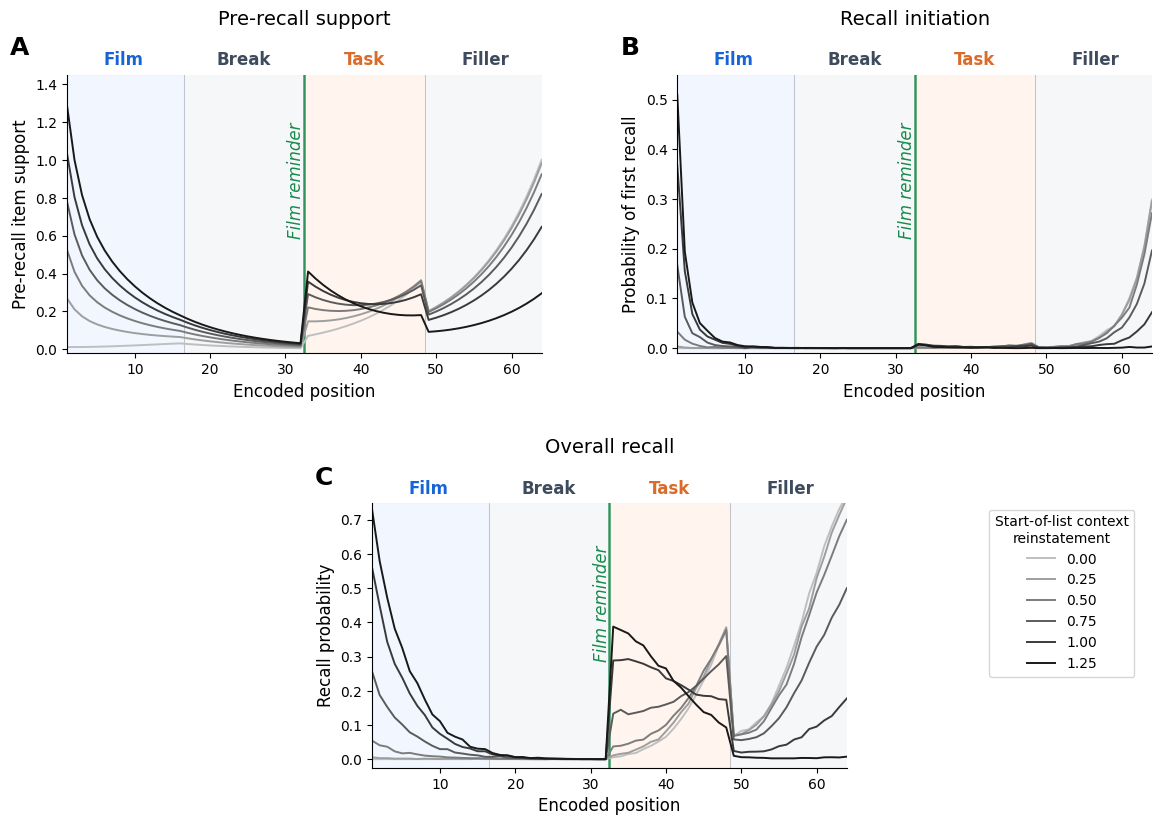

In [9]:
PANEL_LETTER_FONTSIZE = 18
PANEL_TITLE_FONTSIZE = 14
STRUCTURAL_FONTSIZE = 12
SUPPORT_FONTSIZE = 10


def add_panel_label(axis, label, x=-0.12):
    axis.text(
        x,
        1.14,
        label,
        transform=axis.transAxes,
        fontsize=PANEL_LETTER_FONTSIZE,
        fontweight="bold",
        va="top",
        ha="left",
    )


def add_phase_boundaries(axis):
    boundaries = np.cumsum([
        paradigm.n_film,
        paradigm.n_break,
        paradigm.n_interference,
    ]) + 0.5
    for boundary in boundaries:
        axis.axvline(boundary, color="#7C8794", linewidth=0.7, alpha=0.45, zorder=1)


def add_reminder_marker(axis, show_label=False):
    reminder_x = paradigm.n_film + paradigm.n_break + 0.5
    axis.axvline(
        reminder_x,
        color=PHASE_COLORS["reminder"],
        linewidth=1.8,
        alpha=0.85,
        zorder=2,
    )
    if show_label:
        axis.text(
            reminder_x - 1.05,
            0.62,
            "Film reminder",
            ha="center",
            va="center",
            fontsize=STRUCTURAL_FONTSIZE,
            fontstyle="italic",
            color=PHASE_COLORS["reminder"],
            rotation=90,
            rotation_mode="anchor",
            transform=axis.get_xaxis_transform(),
            clip_on=False,
            zorder=3,
        )


def style_position_axis(axis, ylabel, title, show_reminder_label=False):
    add_phase_bands(axis, position_phase, fontsize=STRUCTURAL_FONTSIZE)
    add_phase_boundaries(axis)
    add_reminder_marker(axis, show_label=show_reminder_label)
    axis.set_title(title, fontsize=PANEL_TITLE_FONTSIZE, pad=36)
    axis.set_xlabel("Encoded position", fontsize=STRUCTURAL_FONTSIZE)
    axis.set_ylabel(ylabel, fontsize=STRUCTURAL_FONTSIZE)
    axis.set_xlim(1, n_presented)
    axis.tick_params(labelsize=SUPPORT_FONTSIZE)
    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)


def plot_position_curves(axis, curves, ylabel, title, ylim, show_reminder_label=False):
    style_position_axis(axis, ylabel, title, show_reminder_label=show_reminder_label)
    colors = light_to_dark_colors(len(sweep_values))
    positions = np.arange(1, n_presented + 1)
    for color, value, curve in zip(colors, sweep_values, curves):
        axis.plot(
            positions,
            curve,
            color=color,
            linewidth=1.4,
            label=SWEEP_LABEL_FMT.format(value),
        )
    axis.set_ylim(*ylim)


fig = plt.figure(figsize=(14, 9))
gs = fig.add_gridspec(
    2,
    4,
    height_ratios=[1.05, 1.0],
    hspace=0.55,
    wspace=0.80,
)

axis_a = fig.add_subplot(gs[0, 0:2])
axis_b = fig.add_subplot(gs[0, 2:4], sharex=axis_a)
axis_c = fig.add_subplot(gs[1, 1:3], sharex=axis_a)
legend_axis = fig.add_subplot(gs[1, 3])
legend_axis.axis("off")

plot_position_curves(
    axis_a,
    support_curves,
    "Pre-recall item support",
    "Pre-recall support",
    (-0.02, 1.45),
    show_reminder_label=True,
)
plot_position_curves(
    axis_b,
    pfr_curves,
    "Probability of first recall",
    "Recall initiation",
    (-0.01, 0.55),
    show_reminder_label=True,
)
plot_position_curves(
    axis_c,
    spc_curves,
    "Recall probability",
    "Overall recall",
    (-0.025, 0.75),
    show_reminder_label=True,
)

add_panel_label(axis_a, "A")
add_panel_label(axis_b, "B")
add_panel_label(axis_c, "C")

handles, labels = axis_a.get_legend_handles_labels()
legend = legend_axis.legend(
    handles,
    labels,
    title=SWEEP_XLABEL,
    loc="upper left",
    fontsize=SUPPORT_FONTSIZE,
    title_fontsize=SUPPORT_FONTSIZE,
)
legend.get_title().set_multialignment("center")
legend.get_title().set_ha("center")

save_figure(str(figure_dir) if figure_dir is not None else "", FIGURE_STR)

In [10]:
film_positions = [i for i, phase in enumerate(position_phase) if phase == "film"]
task_positions = [i for i, phase in enumerate(position_phase) if phase == "task"]
for idx, value in enumerate(sweep_values):
    film_support = float(np.sum(np.asarray(support_curves[idx])[film_positions]))
    task_support = float(np.sum(np.asarray(support_curves[idx])[task_positions]))
    film_pfr = float(np.sum(np.asarray(pfr_curves[idx])[film_positions]))
    task_pfr = float(np.sum(np.asarray(pfr_curves[idx])[task_positions]))
    film_spc = float(np.sum(np.asarray(spc_curves[idx])[film_positions]))
    task_spc = float(np.sum(np.asarray(spc_curves[idx])[task_positions]))
    print(f"Start-of-list context reinstatement {value:.2f} x beta_start")
    print(f"  Initial support share, film/task: {film_support:.3f} / {task_support:.3f}")
    print(f"  First-recall probability, film/task: {film_pfr:.3f} / {task_pfr:.3f}")
    print(f"  Recall probability mass, film/task: {film_spc:.3f} / {task_spc:.3f}")

Start-of-list context reinstatement 0.00 x beta_start
  Initial support share, film/task: 0.313 / 2.875
  First-recall probability, film/task: 0.000 / 0.024
  Recall probability mass, film/task: 0.001 / 1.988
Start-of-list context reinstatement 0.25 x beta_start
  Initial support share, film/task: 1.870 / 3.447
  First-recall probability, film/task: 0.006 / 0.034
  Recall probability mass, film/task: 0.026 / 2.168
Start-of-list context reinstatement 0.50 x beta_start
  Initial support share, film/task: 3.411 / 3.905
  First-recall probability, film/task: 0.071 / 0.045
  Recall probability mass, film/task: 0.251 / 2.423
Start-of-list context reinstatement 0.75 x beta_start
  Initial support share, film/task: 4.936 / 4.227
  First-recall probability, film/task: 0.315 / 0.061
  Recall probability mass, film/task: 1.180 / 2.981
Start-of-list context reinstatement 1.00 x beta_start
  Initial support share, film/task: 6.440 / 4.351
  First-recall probability, film/task: 0.703 / 0.058
  Recal